# Recurrent Reservoir Model — Notebook Edition

This notebook reconstructs the full project code from the three source files
so it can be explored and executed interactively:

- `model_setup.py` — model configuration, weight matrices, dynamics, and the linear decoder
- `plotting.py` — diagnostic plotting helpers
- `run_model.py` — the simulation loop and the end-to-end experiment

Run the cells top to bottom. Figures render inline instead of being saved to SVG
(a saving helper is provided at the end if you want files as well).

## 1. Imports and setup

In [3]:
%matplotlib inline

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import numpy as np
import matplotlib.pyplot as plt

Array = np.ndarray

# Optional: fix the random seed for reproducible runs.
# np.random.seed(0)

## 2. Model configuration (`model_setup.py`)

The model has three main parts: a recurrent reservoir of `N` neurons, a sparse
input projection from `nIn` possible external inputs, and an optional linear
decoder that reads input labels from reservoir activity.

In [4]:
@dataclass
class ModelConfig:
    """Configuration values for the recurrent neural network model.

    The model has three main parts:
    1. a recurrent reservoir of ``N`` neurons,
    2. a sparse input projection from ``nIn`` possible external inputs,
    3. an optional linear decoder that reads input labels from reservoir activity.

    Keeping these values in a dataclass makes it easy to run controlled
    experiments by changing only the configuration object.
    """

    # Recurrent pool
    # Number of neurons in the recurrent reservoir.
    N: int = 1000
    # Gain of the recurrent weight matrix. Values close to 1 keep activity rich
    # while usually avoiding unstable runaway dynamics.
    g: float = 0.95
    # Fraction of non-zero recurrent connections.
    sp: float = 0.25
    # Membrane/activity time constant in milliseconds.
    tau: float = 20.0
    # Simulation time step in milliseconds.
    dt: float = 0.1
    # Nonlinearity applied to recurrent activity after each integration step.
    nonlin: Callable[[Array], Array] = np.tanh

    # Input layer
    # Number of distinct non-zero input classes. Class 0 is reserved for silence.
    nIn: int = 20
    # Gain of the input weight matrix.
    gIn: float = 10.0
    # Fraction of non-zero input-to-reservoir connections.
    spIn: float = 0.05
    # Initial silent period before the first stimulus, in milliseconds.
    burnIn: float = 10.0
    # Duration of each presented stimulus, in milliseconds.
    durIn: float = 1.0
    # Inter-stimulus interval, in milliseconds.
    ISI: float = 0.0
    # Optional transformation of the one-hot input vector before projection.
    nonlinIn: Callable[[Array], Array] = lambda x: x

    # Linear decoder
    # Ridge penalty used when fitting the readout. This stabilizes the matrix
    # inverse when neurons are correlated or training data are limited.
    decode_regularization: float = 1.0
    # If true, append a constant feature so the decoder can learn class offsets.
    decode_include_bias: bool = True

In [5]:
@dataclass
class Model:
    """Model configuration together with generated weight matrices."""

    # Hyperparameters and simulation constants.
    config: ModelConfig
    # Recurrent reservoir weights with shape (N, N).
    J: Array
    # Input projection weights with shape (N, nIn).
    Jin: Array
    # Decoder/readout weights with shape (nIn + 1, N [+ bias]).
    # This is filled by fit_decoder and left as None before training.
    Jout: Array | None = None

### 2.1 Building the weight matrices

In [6]:
def create_weight_matrix(
    rows: int,
    columns: int,
    sparsity: float,
    gain: float,
    normalization_size: int,
) -> Array:
    """Create a sparse random weight matrix with normalized variance.

    The random Gaussian matrix supplies the raw weights. The sparse mask then
    removes connections with probability ``1 - sparsity``. Finally, the scaling
    by ``sqrt(normalization_size * sparsity)`` keeps the expected input variance
    comparable when changing layer size or sparsity.
    """
    random_values = np.random.normal(0, 1, size=(rows, columns))
    sparse_mask = np.random.uniform(0, 1, size=(rows, columns)) <= sparsity
    return random_values * sparse_mask * gain / math.sqrt(normalization_size * sparsity)


def build_model(config: ModelConfig | None = None) -> Model:
    """Create the recurrent and input weight matrices for one model instance."""
    config = config or ModelConfig()

    # The recurrent matrix maps the reservoir state at time t back into the
    # reservoir. Its normalization uses N because each neuron receives from the
    # recurrent population.
    recurrent_weights = create_weight_matrix(
        rows=config.N,
        columns=config.N,
        sparsity=config.sp,
        gain=config.g,
        normalization_size=config.N,
    )
    # The input matrix maps the external one-hot input into the reservoir. Its
    # normalization uses nIn because each neuron receives from the input layer.
    input_weights = create_weight_matrix(
        rows=config.N,
        columns=config.nIn,
        sparsity=config.spIn,
        gain=config.gIn,
        normalization_size=config.nIn,
    )

    return Model(config=config, J=recurrent_weights, Jin=input_weights)

In [7]:
littleBrain= build_model()
print(littleBrain.Jin[910])

[-0.  0. -0.  0.  0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0.  0.  0. -0.
 -0. -0.]


### 2.2 Decoder targets and features

In [8]:
def make_decode_targets(input_stream: Array, config: ModelConfig) -> Array:
    """Create one-hot decoder targets, including class 0 for no input.

    ``input_stream`` stores one integer label per time step. The decoder is fit
    against a one-hot matrix because it predicts one score for every possible
    class, including the silent/no-input class.
    """
    targets = np.zeros((config.nIn + 1, input_stream.size))
    targets[input_stream, np.arange(input_stream.size)] = 1.0
    return targets


def add_decoder_bias(firing_rates: Array) -> Array:
    """Append a constant bias row to decoder features.

    Firing rates are stored as (neurons, time). Appending a row of ones gives
    the linear decoder an intercept term without changing the time dimension.
    """
    bias = np.ones((1, firing_rates.shape[1]))
    return np.vstack((firing_rates, bias))

In [10]:
example_stream = np.array([0, 1, 2, 0, 3])
example_target = make_decode_targets(example_stream, littleBrain.config)
print(example_target.shape)


(21, 5)


In [11]:
example_rates = np.random.uniform(0, 1, size=(4, 5))  # 4 "neurons", 5 time steps
example_features = add_decoder_bias(example_rates)

print("firing_rates shape:", example_rates.shape)
print("features shape:", example_features.shape)
print(example_features)

firing_rates shape: (4, 5)
features shape: (5, 5)
[[0.87859314 0.57445145 0.91568807 0.35460695 0.56315622]
 [0.71093988 0.39220007 0.90429403 0.95467215 0.02275694]
 [0.49273813 0.80747764 0.31694085 0.44683962 0.10457603]
 [0.81169413 0.01596668 0.69376409 0.50478427 0.04364963]
 [1.         1.         1.         1.         1.        ]]


### 2.3 Fitting and applying the ridge-regression decoder

In [ ]:
def fit_decoder(
    model: Model,
    firing_rates: Array,
    target_stream: Array,
    regularization: float | None = None,
) -> Array:
    """Fit a ridge-regression readout from firing rates to input classes.

    The returned matrix maps reservoir features to class scores:

        decoded_scores = Jout @ features

    where ``features`` are either firing rates alone or firing rates plus a
    constant bias row. The same weights are also stored on ``model.Jout`` so
    ``decode`` can be called later on held-out simulations.
    """
    config = model.config
    regularization = (
        config.decode_regularization if regularization is None else regularization
    )

    # Convert integer labels into one-hot rows. This gives the least-squares
    # problem one target row per class.
    targets = make_decode_targets(target_stream, config)
    features = (
        add_decoder_bias(firing_rates)
        if config.decode_include_bias
        else firing_rates
    )

    # Ridge-regression normal equation:
    # Jout = targets @ features.T @ inv(features @ features.T + lambda * I)
    # The solve below avoids explicitly forming an inverse, which is numerically
    # better and usually faster.
    gram = features @ features.T
    if regularization > 0:
        gram = gram + regularization * np.eye(gram.shape[0])

    decoder_weights = np.linalg.solve(gram, (targets @ features.T).T).T
    model.Jout = decoder_weights

    return decoder_weights


def decode(model: Model, firing_rates: Array) -> Array:
    """Decode input-class scores from firing rates using the fitted readout."""
    if model.Jout is None:
        raise ValueError("Decoder has not been fit. Call fit_decoder first.")

    # Match the feature layout used during training. If a bias row was included
    # when fitting, it must also be included when decoding new activity.
    features = (
        add_decoder_bias(firing_rates)
        if model.config.decode_include_bias
        else firing_rates
    )
    return model.Jout @ features


def decoded_stream(decoded_scores: Array) -> Array:
    """Convert decoder scores into predicted input labels.

    The winning class is the row with the largest score at each time step.
    """
    return np.argmax(decoded_scores, axis=0).astype(int)


def decode_accuracy(
    decoded_scores: Array,
    target_stream: Array,
    mask: Array | None = None,
) -> float:
    """Measure the fraction of correctly decoded labels.

    ``mask`` can be used to evaluate only selected time points, for example
    periods where an input is active (``target_stream > 0``). If the mask
    excludes every time point, the function returns NaN instead of raising.
    """
    predicted_stream = decoded_stream(decoded_scores)

    if mask is None:
        mask = np.ones(target_stream.shape, dtype=bool)

    if not np.any(mask):
        return float("nan")

    return float(np.mean(predicted_stream[mask] == target_stream[mask]))

### 2.4 Network dynamics and input generation

In [ ]:
def step(firing_rates: Array, input_layer: Array, model: Model) -> Array:
    """Advance the firing rates by one Euler-style integration step.

    ``firing_rates`` is the reservoir state at one time point and ``input_layer``
    is the external input vector at the same time point. The update mixes the old
    state with the current recurrent/input drive according to the time constant,
    then applies the reservoir nonlinearity.
    """
    config = model.config
    # Exact decay factor for a first-order low-pass process over one time step.
    timestep = math.exp(-config.dt / config.tau)

    # Total synaptic drive from recurrent activity plus external input.
    input_drive = model.J @ firing_rates + model.Jin @ config.nonlinIn(input_layer)
    # Relax the old rates toward the current drive and squash them through the
    # nonlinear activation function.
    updated_rates = config.nonlin(input_drive + (firing_rates - input_drive) * timestep)

    return updated_rates


def make_input(sequence_length: int, config: ModelConfig) -> tuple[Array, Array]:
    """Generate a random input sequence as one-hot and integer streams.

    The integer stream contains class labels at every time step. Label 0 means
    no input. The returned one-hot matrix excludes row 0 because only the active
    input channels are projected into the reservoir.
    """
    burn_in_steps = int(config.burnIn / config.dt)
    isi_steps = int(config.ISI / config.dt)
    input_duration_steps = int(config.durIn / config.dt)

    # Begin with silence so the reservoir has time to settle before stimuli.
    input_stream = [0] * burn_in_steps

    for _ in range(sequence_length):
        # Input labels are 1..nIn because 0 is reserved for silence.
        value = np.random.randint(0, config.nIn) + 1
        input_stream.extend([0] * isi_steps)
        input_stream.extend([value] * input_duration_steps)

    input_stream = np.array(input_stream, dtype=int)

    # Build a full one-hot representation with a row for silence, then drop the
    # silence row before returning because the input layer has only nIn channels.
    onehot = np.zeros((config.nIn + 1, input_stream.size))
    onehot[input_stream, np.arange(input_stream.size)] = 1.0

    return onehot[1:, :], input_stream

## 3. Plotting helpers (`plotting.py`)

In the standalone script these used a `get_pyplot()` helper to import matplotlib
lazily. In the notebook matplotlib is already imported as `plt` above, so the
functions use it directly. Each function returns the figure so it renders inline.

In [ ]:
def plot_input_stream(onehot: Array, stream: Array, config: ModelConfig):
    """Plot the generated input as values and one-hot activity."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    omit = int(config.burnIn / config.dt)

    ax[0].plot(np.arange(len(stream) - omit) * config.dt, stream[omit:])
    ax[0].set_xlabel("time (ms)")
    ax[0].set_ylabel("input value")

    ax[1].imshow(onehot[:, omit:], aspect="auto")
    ax[1].set_xlabel("time (ms)")
    ax[1].set_ylabel("input one-hot encoding")

    fig.tight_layout()
    return fig

In [ ]:
def plot_weight_matrix_and_spectrum(model: Model, show_count: int = 50):
    """Plot a sample of J and its eigenvalue spectrum."""
    eigenvalues, _ = np.linalg.eig(model.J)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sample = ax[0].imshow(model.J[:show_count, :show_count])
    ax[0].set_title("Sample from weight matrix J")
    ax[0].set_xlabel("presynaptic neuron")
    ax[0].set_ylabel("postsynaptic neuron")
    plt.colorbar(sample, ax=ax[0])

    circle = np.linspace(0, 2 * math.pi, 100)
    ax[1].plot(np.real(eigenvalues), np.imag(eigenvalues), ".")
    ax[1].plot(np.sin(circle), np.cos(circle))
    ax[1].set_title("Eigenvalue spectrum of J")
    ax[1].set_xlabel("real component")
    ax[1].set_ylabel("imaginary component")

    fig.tight_layout()
    return fig

In [ ]:
def plot_simulation(firing_rates: Array, input_stream: Array, config: ModelConfig):
    """Plot the input stream and simulated neural activity."""
    fig, ax = plt.subplots(2, 1, figsize=(8, 12))
    simulation_time = np.arange(len(input_stream)) * config.dt - config.burnIn

    ax[0].plot(simulation_time, input_stream)
    ax[0].set_xlabel("Time (ms)")
    ax[0].set_ylabel("Input value")

    extents = [simulation_time[0], simulation_time[-1], 0, config.N]
    ax[1].imshow(firing_rates, aspect="auto", extent=extents)
    ax[1].set_xlabel("Time (ms)")
    ax[1].set_ylabel("Neurons")

    fig.tight_layout()
    return fig

In [ ]:
def plot_decoder_accuracy(
    decoded_scores: Array,
    target_stream: Array,
    config: ModelConfig,
    mask: Array | None = None,
    window_ms: float = 5.0,
):
    """Plot decoder performance over time.

    The upper panel compares the true input labels with the decoder's predicted
    labels. The lower panel shows a rolling accuracy trace, which is easier to
    read than single-time-step correctness when many samples are plotted.

    Parameters
    ----------
    decoded_scores:
        Decoder output with shape (classes, time).
    target_stream:
        Integer class labels with one value per decoded time step.
    config:
        Model configuration used to convert samples to milliseconds.
    mask:
        Optional boolean array selecting which time points should count toward
        the reported and rolling accuracy. Use ``target_stream > 0`` to focus on
        time points where an input is present.
    window_ms:
        Width of the rolling accuracy window in milliseconds.
    """
    if decoded_scores.shape[1] != target_stream.size:
        raise ValueError("decoded_scores and target_stream must have matching time axes.")

    predicted_stream = decoded_stream(decoded_scores)
    correct = predicted_stream == target_stream

    if mask is None:
        mask = np.ones(target_stream.shape, dtype=bool)
        title_suffix = "all time points"
    else:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != target_stream.shape:
            raise ValueError("mask must have the same shape as target_stream.")
        title_suffix = "masked time points"

    accuracy = decode_accuracy(decoded_scores, target_stream, mask)

    # Convert the requested time window to samples and keep at least one sample
    # so very small windows still produce a valid rolling trace.
    window_steps = min(target_stream.size, max(1, int(round(window_ms / config.dt))))
    weights = np.ones(window_steps)

    # Rolling accuracy should ignore samples outside the mask rather than
    # treating them as wrong. Dividing by the rolling count of selected samples
    # handles windows that only partially overlap the mask.
    rolling_correct = np.convolve(correct * mask, weights, mode="same")
    rolling_count = np.convolve(mask.astype(float), weights, mode="same")
    rolling_accuracy = np.divide(
        rolling_correct,
        rolling_count,
        out=np.full_like(rolling_correct, np.nan, dtype=float),
        where=rolling_count > 0,
    )

    time = np.arange(target_stream.size) * config.dt
    fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax[0].plot(time, target_stream, label="target", linewidth=1.5)
    ax[0].plot(time, predicted_stream, label="decoded", linewidth=1.0, alpha=0.8)
    ax[0].set_ylabel("input class")
    ax[0].set_title(f"Decoder labels ({title_suffix})")
    ax[0].legend(loc="upper right")

    ax[1].plot(time, rolling_accuracy, color="tab:green", linewidth=1.5)
    ax[1].axhline(accuracy, color="black", linestyle="--", linewidth=1.0)
    ax[1].set_ylim(-0.02, 1.02)
    ax[1].set_xlabel("Time (ms)")
    ax[1].set_ylabel("accuracy")
    ax[1].set_title(f"Decoder accuracy = {accuracy:.3f}")

    fig.tight_layout()
    return fig

## 4. Simulation loop (`run_model.py`)

`simulate` integrates the reservoir forward in time. The activity at time `t`
and the input at time `t` determine the activity written into time `t + 1`.

In [ ]:
def simulate(model: Model, sequence_length: int) -> tuple[Array, Array, Array]:
    """Run the recurrent network and return activity plus the generated input.

    The returned arrays share the same time axis:
    - ``firing_rates`` has shape (neurons, time),
    - ``onehot`` has shape (input channels, time),
    - ``input_stream`` stores the integer input label at each time step.
    """
    config = model.config

    # Create the stimulus sequence for this run. The one-hot version drives the
    # model, while the integer stream is easier to plot and use as decoder labels.
    onehot, input_stream = make_input(sequence_length, config)

    # Store every neuron's firing rate at every time step. The first column is
    # initialized with small random activity so the reservoir does not start from
    # a perfectly silent, symmetric state.
    firing_rates = np.zeros((config.N, len(input_stream)))
    firing_rates[:, 0] = np.random.uniform(0, 0.1, size=config.N)

    # Integrate forward one time step at a time. The activity at time t and the
    # input at time t determine the activity written into time t + 1.
    for t in range(len(input_stream) - 1):
        firing_rates[:, t + 1] = step(firing_rates[:, t], onehot[:, t], model)

    return firing_rates, onehot, input_stream

## 5. Run the experiment

The following cells reproduce `run_model.main()` step by step, showing each
figure inline. Build one random reservoir instance from the default config.

In [ ]:
config = ModelConfig()
model = build_model(config)
config

ModelConfig(N=1000, g=0.95, sp=0.25, tau=20.0, dt=0.1, nonlin=<ufunc 'tanh'>, nIn=20, gIn=10.0, spIn=0.05, burnIn=10.0, durIn=1.0, ISI=0.0, nonlinIn=<function ModelConfig.<lambda> at 0x713f156a9e40>, decode_regularization=1.0, decode_include_bias=True)

### 5.1 Example input sequence

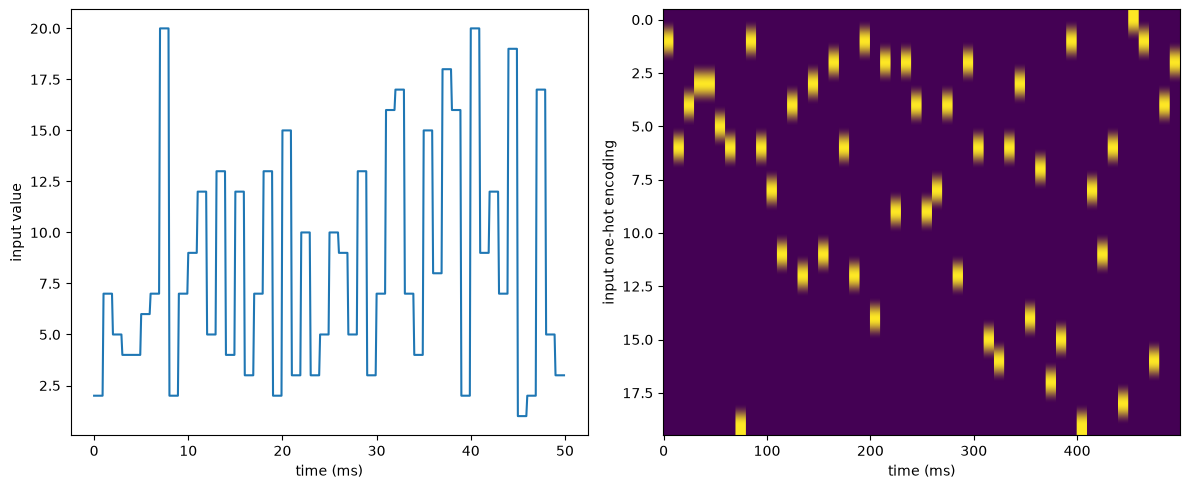

In [ ]:
onehot, stream = make_input(sequence_length=50, config=config)
plot_input_stream(onehot, stream, config)
plt.show()

### 5.2 Recurrent weight matrix and eigenvalue spectrum

A sample of `J` and its eigenvalue spectrum, to verify that the reservoir
weights have the expected scale relative to the unit circle.

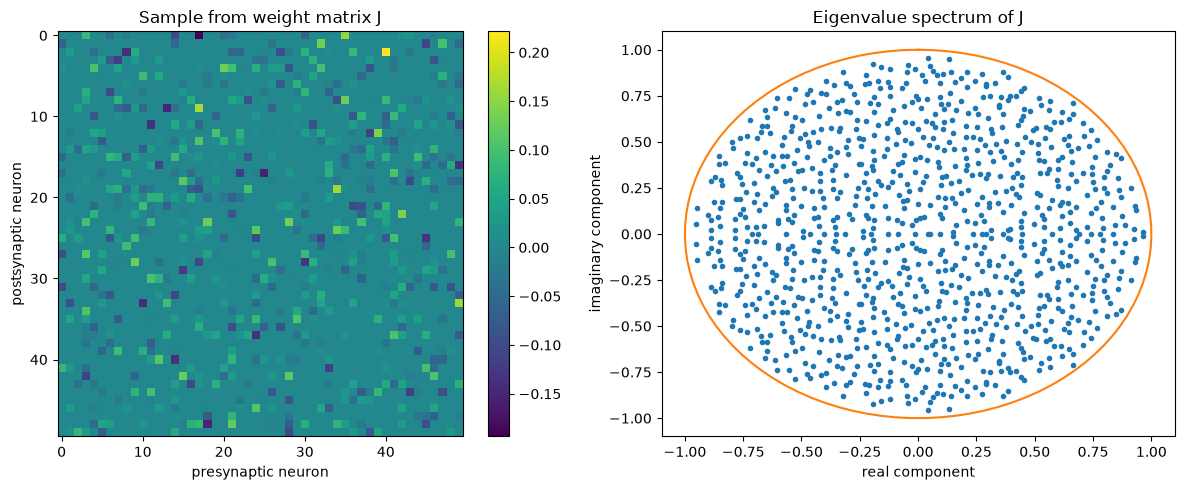

In [ ]:
plot_weight_matrix_and_spectrum(model)
plt.show()

### 5.3 Short simulation of reservoir activity

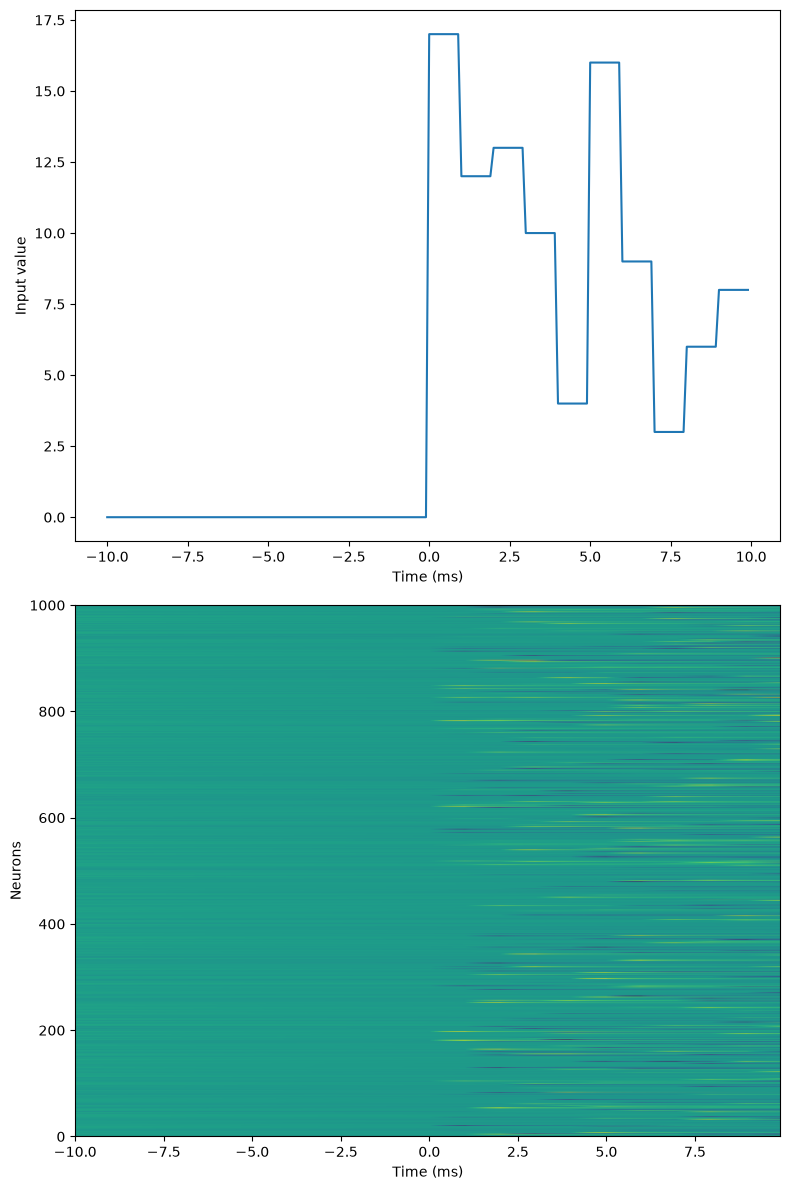

In [ ]:
firing_rates, _, input_stream = simulate(model, sequence_length=10)
plot_simulation(firing_rates, input_stream, config)
plt.show()

### 5.4 Train the decoder

Train on an independent, longer simulation. Because each integration step
writes activity at `t + 1` from input at `t`, the decoder is fit on
`train_rates[:, 1:]` against `train_stream[:-1]`.

In [ ]:
train_rates, _, train_stream = simulate(model, sequence_length=500)
fit_decoder(model, train_rates[:, 1:], train_stream[:-1])
print("Decoder fitted. Jout shape:", model.Jout.shape)

Decoder fitted. Jout shape: (21, 1001)


### 5.5 Test the decoder on held-out activity

Evaluate on a fresh simulation so the reported performance is measured on data
that were not used to fit the readout weights. We report accuracy over all time
points and over only the time points where an input is actually present.

In [ ]:
test_rates, _, test_stream = simulate(model, sequence_length=100)
decoded_scores = decode(model, test_rates[:, 1:])
decode_targets = test_stream[:-1]

active_input_mask = decode_targets > 0
overall_accuracy = decode_accuracy(decoded_scores, decode_targets)
active_accuracy = decode_accuracy(decoded_scores, decode_targets, active_input_mask)

print(f"Decode accuracy: {overall_accuracy:.3f}")
print(f"Decode accuracy while input is active: {active_accuracy:.3f}")

Decode accuracy: 0.883
Decode accuracy while input is active: 0.871


### 5.6 Decoder diagnostic plot

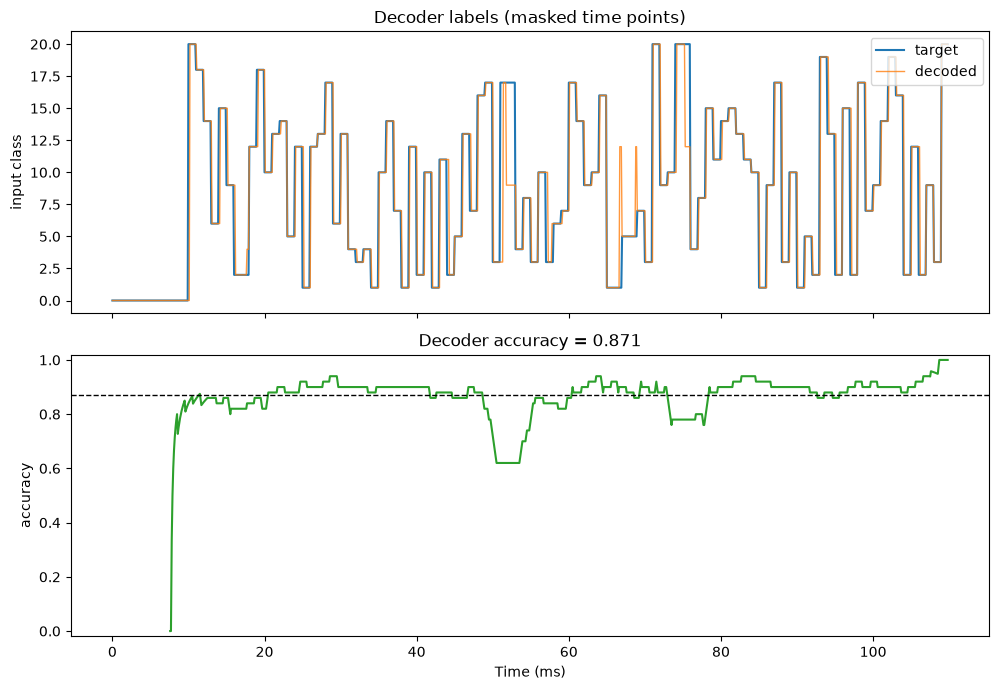

In [ ]:
plot_decoder_accuracy(
    decoded_scores,
    decode_targets,
    config,
    mask=active_input_mask,
)
plt.show()

## 6. Optional: save figures to disk

The original script saved SVGs into a project-level `plots/` directory. Run the
cell below if you want the same files. Figures are re-generated here so the cell
is self-contained regardless of what is currently shown inline.

In [ ]:
def save_svg(fig, filename: str, plots_dir: Path) -> Path:
    """Save a matplotlib figure as SVG in the given plots directory."""
    plots_dir.mkdir(exist_ok=True)
    output_path = plots_dir / filename
    fig.savefig(output_path, format="svg", bbox_inches="tight")
    return output_path


# Resolve a plots directory relative to where the notebook runs.
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "code" else notebook_dir
plots_dir = project_root / "plots"

# Re-generate each figure so this cell is self-contained.
_onehot, _stream = make_input(sequence_length=50, config=config)
_sim_rates, _, _sim_stream = simulate(model, sequence_length=10)

figures = {
    "input_stream.svg": plot_input_stream(_onehot, _stream, config),
    "weight_matrix_and_spectrum.svg": plot_weight_matrix_and_spectrum(model),
    "simulation_activity.svg": plot_simulation(_sim_rates, _sim_stream, config),
    "decoder_accuracy.svg": plot_decoder_accuracy(
        decoded_scores, decode_targets, config, mask=active_input_mask,
    ),
}

for name, fig in figures.items():
    path = save_svg(fig, name, plots_dir)
    print("Saved", path)

plt.close("all")

Saved /home/phil/Documents/SummerSchool/plots/input_stream.svg
Saved /home/phil/Documents/SummerSchool/plots/weight_matrix_and_spectrum.svg
Saved /home/phil/Documents/SummerSchool/plots/simulation_activity.svg
Saved /home/phil/Documents/SummerSchool/plots/decoder_accuracy.svg
